In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import itertools

import numpy as np
import shapely
from matplotlib import pyplot as plt
from shapely.ops import unary_union

from funbin.geometry import Box, Point, Polygon, as_poly_collection
from funbin.maps import read_shapefile

In [3]:
countries = read_shapefile("../misc/ne_110m_admin_0_countries.zip")
countries = [c.scaled(np.pi / 180) for c in countries]
bbox = Box(Point(-np.pi, -np.pi / 2), 2 * np.pi, np.pi)

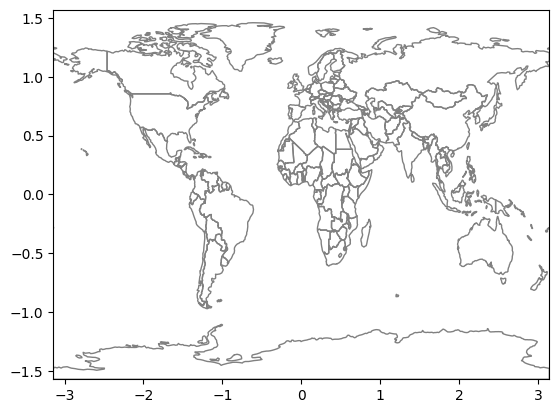

In [4]:
fig, ax = plt.subplots()

ax.add_collection(as_poly_collection(countries))
bbox.fit_axes(ax)

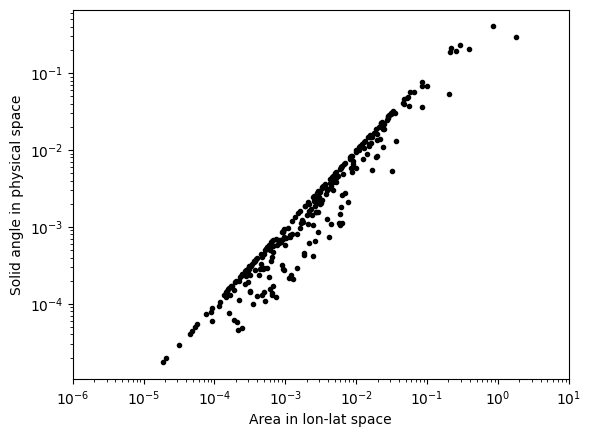

In [9]:
As = []
Omegas = []
for country in countries:
    As.append(country.area)
    Omegas.append(country.solid_angle)

fig, ax = plt.subplots()

ax.set_xscale("log")
ax.set_yscale("log")
ax.scatter(As, Omegas, color="k", marker=".")
ax.set_xlim(1e-6, 10)
ax.set_xlabel("Area in lon-lat space")
ax.set_ylabel("Solid angle in physical space");

In [10]:
sh_polygons = [p.to_shapely() for p in countries]
negative = bbox.as_polygon.to_shapely().difference(unary_union(sh_polygons))

if isinstance(negative, shapely.Polygon):
    sh_negpolygons = [negative]
elif isinstance(negative, shapely.MultiPolygon):
    sh_negpolygons = list(negative.geoms)
else:
    sh_negpolygons = []

print(f"Original: {len(sh_polygons)}, Added: {len(sh_negpolygons)}")

Original: 288, Added: 2


In [11]:
def intersect_with_tiling(shp: shapely.Polygon, tiling: list[Polygon]) -> list[Polygon]:
    ocean_tiles = []
    for tile in tiling:
        intersection = shp.intersection(tile.to_shapely())
        match intersection:
            case shapely.Polygon():
                isect_shpolys = [intersection]
            case shapely.MultiPolygon():
                isect_shpolys = intersection.geoms
            case _:
                continue

        isect_polys = [Polygon.from_shapely(p) for p in isect_shpolys]
        isect_polys = [p for p in isect_polys if p.verts.size > 0 and p.area > 1e-6]
        ocean_tiles.extend(isect_polys)
    return ocean_tiles

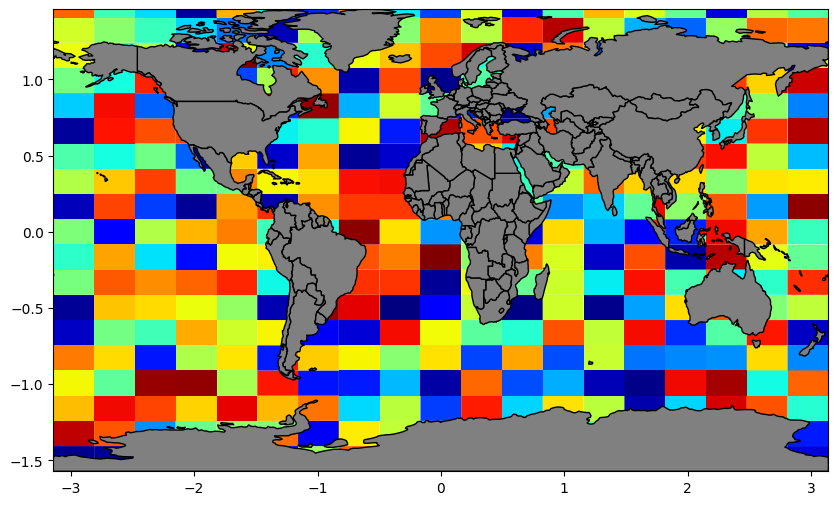

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))


x_grid = np.linspace(-np.pi, np.pi, 20)
y_grid = np.linspace(-np.pi / 2, np.pi / 2, 20)
tiling = []
for xmin, xmax in itertools.pairwise(x_grid):
    for ymin, ymax in itertools.pairwise(y_grid):
        tiling.append(Box(Point(xmin, ymin), (xmax - xmin), (ymax - ymin)).as_polygon)

for shp in sh_negpolygons:
    ax.add_collection(
        as_poly_collection(intersect_with_tiling(shp, tiling=tiling), coloring="random", edgecolor="none")
    )

ax.add_collection(
    as_poly_collection([Polygon.from_shapely(p) for p in sh_polygons], coloring=None, facecolors="gray", edgecolor="k")
)
Box.bounding_all(countries).fit_axes(ax)